<a href="https://colab.research.google.com/github/MonowarHusain/CSE424/blob/main/lab/lab02/Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification Task - Neural Network

MLP = Multi Layer Perceptron

Here we are using Sk-Learn built in MLPClassifier.



```
>hidden_layer_sizes --> (x,y). First hidden layer contains x neurons and second one contains y neurons
>activation --> activation function that is being used
>solver -->   Optimizer. Algorithm used for weight optimization

```

## Using Sk-Learn

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

# Synythetic Dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                           n_redundant=5, n_classes=2, random_state=42)

print(f"Dataset shape: X={X.shape}, y={y.shape}")

#Data splitting using Stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print(f"Training data shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing data shape: X_test={X_test.shape}, y_test={y_test.shape}")


mlp = MLPClassifier(hidden_layer_sizes=(100), activation='relu', solver='adam', max_iter=500, random_state=42)

'''
Hyper-Parameters Used here:
Hidden Layer -> 1 (with 100 neurons)
Activation Layet -> ReLU
Optimizer (Solver) -> AdAM
Epoch (max_iter) -> 500
'''



mlp.fit(X_train, y_train) #Train the model

y_pred = mlp.predict(X_test) #Test the model


accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy of the MLP on the test set: {accuracy:.4f}")

Dataset shape: X=(1000, 20), y=(1000,)
Training data shape: X_train=(700, 20), y_train=(700,)
Testing data shape: X_test=(300, 20), y_test=(300,)

Accuracy of the MLP on the test set: 0.9467


## Using Tensorflow For Binary Classification

In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

# 1. Generate a synthetic tabular dataset (same as before)
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                           n_redundant=5, n_classes=2, random_state=42)

print(f"Dataset shape: X={X.shape}, y={y.shape}")


#Data splitting using Stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print(f"Training data shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing data shape: X_test={X_test.shape}, y_test={y_test.shape}")

#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu', input_shape=(X_train_scaled.shape[1],)), #Hidden Layer --> 100 Neurons with Activation function ReLU
    tf.keras.layers.Dense(1, activation='sigmoid') # OutPut Layer --> Sigmoid for binary classification
])



model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# optimizer='adam' (similar to sklearn solver='adam')
# loss='binary_crossentropy' for binary classification
# metrics=['accuracy'] to track performance during training



model.summary()



history = model.fit(X_train_scaled, y_train, epochs=500, verbose=0, validation_split=0.2)


# 7. Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nAccuracy of the TensorFlow MLP on the test set: {accuracy:.4f}")

Dataset shape: X=(1000, 20), y=(1000,)
Training data shape: X_train=(700, 20), y_train=(700,)
Testing data shape: X_test=(300, 20), y_test=(300,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         2,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,201 (8.60 KB)

 Trainable params: 2,201 (8.60 KB)

 Non-trainable params: 0 (0.00 B)


Accuracy of the TensorFlow MLP on the test set: 0.9400


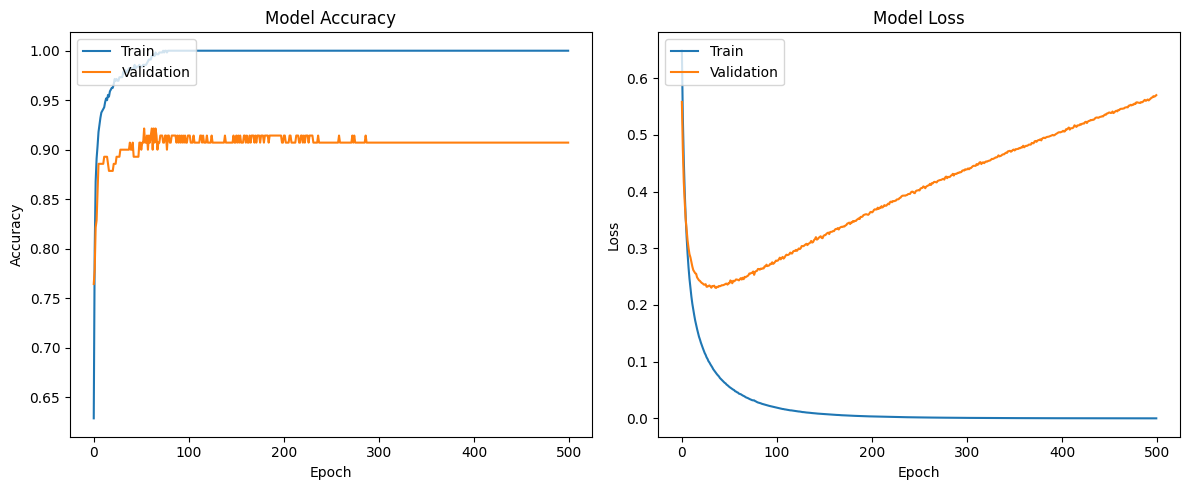

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

## Experimenting with Different Hyper-Parameters




```
Number of hidden layers
Number of neurons per layer
Activation function per layer
Optimizer
Learning Rate
Batch size and epoch
Dropout
Early Stopping
Regularization
Batch Normalization
```





In [ ]:
import tensorflow
from tensorflow.keras import Sequential      #Notice how the library is imported
from tensorflow.keras.layers import Dense, Dropout    #Notice how the library is imported
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

# 1. Generate a synthetic tabular dataset (same as before)
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                           n_redundant=5, n_classes=2, random_state=42)

print(f"Dataset shape: X={X.shape}, y={y.shape}")


#Data splitting using Stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print(f"Training data shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing data shape: X_test={X_test.shape}, y_test={y_test.shape}")

# Reshape y_train and y_test to be 2D arrays for metrics that expect it (like f1_score)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)), #Hidden Layer 1--> 100 Neurons with Activation function ReLU
    Dense(64, activation='relu'),  #Hidden Layer 2 --> 64 Neurons with Activation function ReLU
    Dropout(0.3), #30 percent neurons are randomly deactivated
    Dense(1, activation='sigmoid') # OutPut Layer --> Sigmoid for binary classification
])



model.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['f1_score'])
# optimizer= SGD
# loss='binary_crossentropy' for binary classification
# metrics=['f1_score'] to track performance during training



model.summary()



history = model.fit(X_train_scaled, y_train, epochs=100, batch_size = 24, verbose=0, validation_split=0.2)


# 7. Evaluate the model on the test set
loss, f1_score = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nLoss of the TensorFlow MLP on the test set: {loss:.4f}")
print(f"F1 Score of the TensorFlow MLP on the test set: {f1_score:.4f}")

Dataset shape: X=(1000, 20), y=(1000,)
Training data shape: X_train=(700, 20), y_train=(700,)
Testing data shape: X_test=(300, 20), y_test=(300,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,009 (43.00 KB)

 Trainable params: 11,009 (43.00 KB)

 Non-trainable params: 0 (0.00 B)


Loss of the TensorFlow MLP on the test set: 0.1868
F1 Score of the TensorFlow MLP on the test set: 0.6696


## Multi-Classification  



```
Main Change:
Output Layer will have number of neurons = number of outputs
Output Layer will have softmax as an activation function
Loss function categorical cross entropy
```



In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

# 1. Generate a synthetic tabular dataset (same as before) - For 5 Classes
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                           n_redundant=5, n_classes=5, random_state=42)

print(f"Dataset shape: X={X.shape}, y={y.shape}")


#Data splitting using Stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print(f"Training data shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing data shape: X_test={X_test.shape}, y_test={y_test.shape}")

#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu', input_shape=(X_train_scaled.shape[1],)), #Hidden Layer --> 100 Neurons with Activation function ReLU
    tf.keras.layers.Dense(5, activation='softmax') # OutPut Layer -->
])



model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])




model.summary()



history = model.fit(X_train_scaled, y_train, epochs=500, verbose=0, validation_split=0.2)


# 7. Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nAccuracy of the TensorFlow MLP on the test set: {accuracy:.4f}")

Dataset shape: X=(1000, 20), y=(1000,)
Training data shape: X_train=(700, 20), y_train=(700,)
Testing data shape: X_test=(300, 20), y_test=(300,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 100)            │         2,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 5)              │           505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,605 (10.18 KB)

 Trainable params: 2,605 (10.18 KB)

 Non-trainable params: 0 (0.00 B)


Accuracy of the TensorFlow MLP on the test set: 0.7233


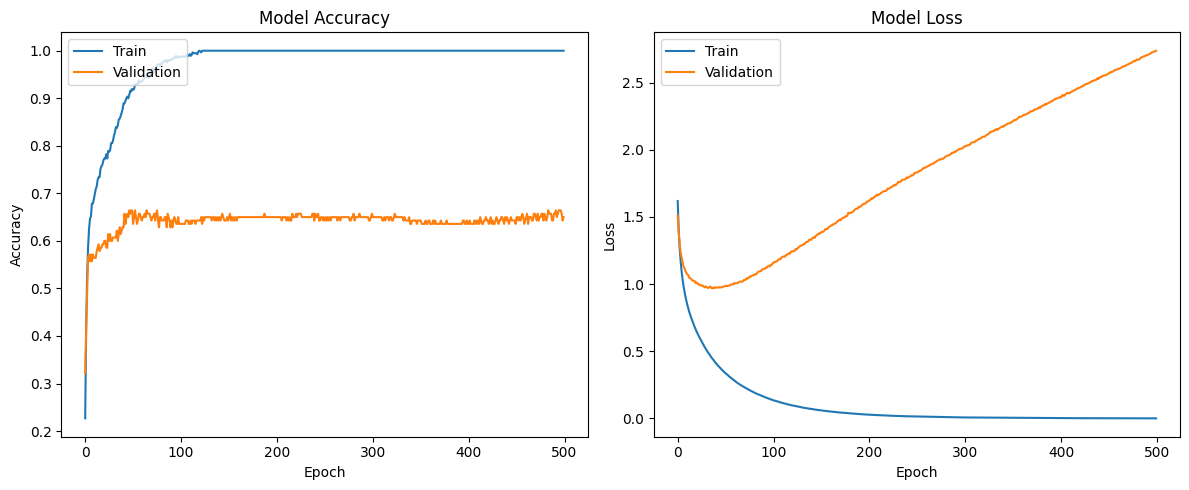

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

# Regression Task


In [ ]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
import tensorflow as tf

# Generate a synthetic regression dataset
X, y = make_regression(n_samples=1000, n_features=20, n_informative=10, random_state=42)

print(f"Dataset shape: X={X.shape}, y={y.shape}")

# Data splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing data shape: X_test={X_test.shape}, y_test={y_test.shape}")

from sklearn.preprocessing import StandardScaler

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# Define the Keras Sequential model for regression
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu', input_shape=(X_train_scaled.shape[1],)), # Hidden layer with ReLU activation
    tf.keras.layers.Dense(50, activation='relu'),  # Another hidden layer
    tf.keras.layers.Dense(1, activation='softmax') # Output layer for regression (1 neuron, no activation for linear output)
])


model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error', 'mean_squared_error'])
# optimizer= 'adam'
# loss='mean_squared_error' for regression task
# metrics=['mean_absolute_error', 'mean_squared_error']  can only be used for regression task


model.summary()

history = model.fit(X_train_scaled, y_train, epochs=500, verbose=0, validation_split=0.2)

# Evaluate the model on the test set
loss, mae, mse = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nLoss on the test set: {loss:.4f}")
print(f"Mean Absolute Error on the test set: {mae:.4f}")
print(f"Mean Squared Error on the test set: {mse:.4f}")

Dataset shape: X=(1000, 20), y=(1000,)
Training data shape: X_train=(700, 20), y_train=(700,)
Testing data shape: X_test=(300, 20), y_test=(300,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 100)            │         2,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,201 (28.13 KB)

 Trainable params: 7,201 (28.13 KB)

 Non-trainable params: 0 (0.00 B)


Loss on the test set: 50.1975
Mean Absolute Error on the test set: 5.2270
Mean Squared Error on the test set: 50.1975


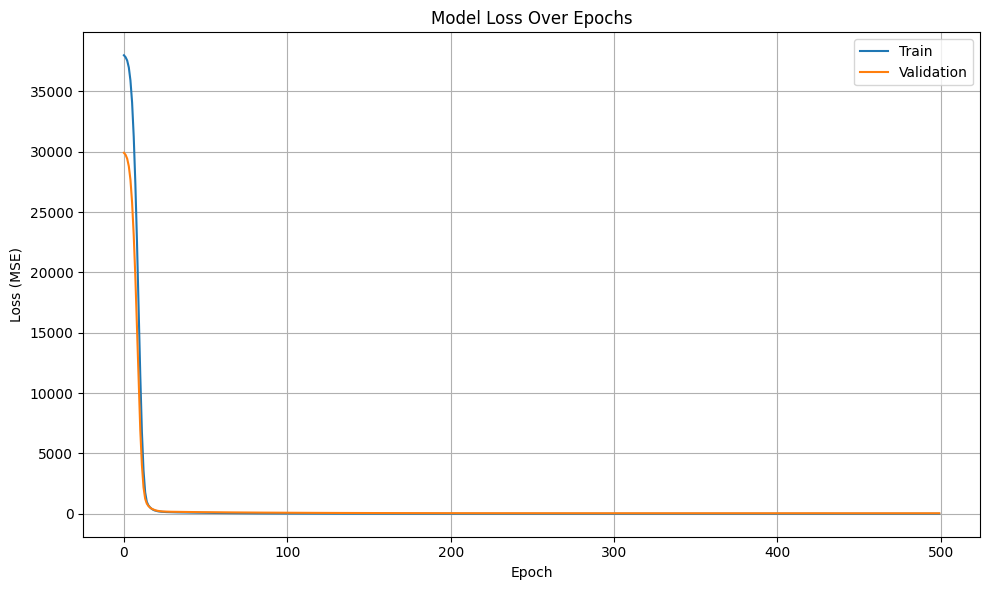

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# RNN

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam

# Reproducibility

np.random.seed(42)
tf.random.set_seed(42)


num_samples = 2000
timesteps = 15
features = 1


X = np.random.randn(num_samples, timesteps, features)

y = (np.mean(X, axis=1) > 0).astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (2000, 15, 1)
y shape: (2000, 1)


In [ ]:
model = Sequential([
    SimpleRNN(32, activation='tanh', input_shape=(timesteps, features)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')   # Binary classification
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,633 (6.38 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X, y,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6871 - loss: 0.5778 - val_accuracy: 0.9175 - val_loss: 0.2236
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9144 - loss: 0.2290 - val_accuracy: 0.9375 - val_loss: 0.1538
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9310 - loss: 0.1709 - val_accuracy: 0.9550 - val_loss: 0.1243
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9454 - loss: 0.1442 - val_accuracy: 0.9550 - val_loss: 0.1070
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9534 - loss: 0.1247 - val_accuracy: 0.9675 - val_loss: 0.0934
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9592 - loss: 0.1075 - val_accuracy: 0.9675 - val_loss: 0.0896
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9700 - loss: 0.0934 - val_accuracy: 0.9600 - val_loss: 0.0947
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9724 - loss: 0.0888 - val_accuracy: 0.9650 - val_loss

In [ ]:
# Generate new test samples
X_test = np.random.randn(10, timesteps, features)
y_test = (np.mean(X_test, axis=1) > 0).astype(int)

pred_probs = model.predict(X_test)
pred_classes = (pred_probs > 0.5).astype(int)

print("True labels:     ", y_test.flatten())
print("Predicted labels:", pred_classes.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
True labels:      [0 0 0 0 1 0 0 1 1 0]
Predicted labels: [0 0 1 0 1 0 0 1 1 0]


## LSTM

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense,Bidirectional
from tensorflow.keras.optimizers import Adam

In [ ]:
model = Sequential([
    Bidirectional(LSTM(64, input_shape=(timesteps, features))),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X, y,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8421 - loss: 0.5546 - val_accuracy: 0.9375 - val_loss: 0.1977
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8835 - loss: 0.2575 - val_accuracy: 0.9525 - val_loss: 0.1217
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9293 - loss: 0.1652 - val_accuracy: 0.9350 - val_loss: 0.1243
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9556 - loss: 0.1024 - val_accuracy: 0.9600 - val_loss: 0.0972
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9729 - loss: 0.0791 - val_accuracy: 0.9575 - val_loss: 0.0908
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9768 - loss: 0.0646 - val_accuracy: 0.9550 - val_loss: 0.0951
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9809 - loss: 0.0599 - val_accuracy: 0.9600 - val_loss: 0.0865
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9818 - loss: 0.0534 - val_accuracy: 0.9625 - val_loss

In [ ]:
# Generate new test data
X_test = np.random.randn(10, timesteps, features)
y_test = (X_test[:, -1, 0] > X_test[:, 0, 0]).astype(int)

pred_probs = model.predict(X_test)
pred_classes = (pred_probs > 0.5).astype(int)

print("True labels:     ", y_test)
print("Predicted labels:", pred_classes.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
True labels:      [1 1 1 0 0 1 1 1 1 1]
Predicted labels: [1 1 1 0 1 1 0 0 1 0]
